<a href="https://colab.research.google.com/github/karan020/stock_price_makrt/blob/main/Stock_price_marekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Step2. Set Random Seeds For Reproductively

In [2]:
np.random.seed(42)

Step3. load the finance dataset

In [3]:
company=yf.Ticker("AAPL")
data=company.history(period="10y")

#Exactly Only the 'Close' price
close_prices=data[['Close']].copy()
print(f"Data Shape:{close_prices.shape}")
print(f"Date range: {close_prices.index[0].strftime('%Y-%m-%d')} to {close_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"\nFirst 5 rows:\n{close_prices.head()}")
print(f"\nLast 5 Rows:\n{close_prices.tail()}")

Data Shape:(2512, 1)
Date range: 2016-07-08 to 2026-07-07

First 5 rows:
                               Close
Date                                
2016-07-08 00:00:00-04:00  22.009169
2016-07-11 00:00:00-04:00  22.077457
2016-07-12 00:00:00-04:00  22.177631
2016-07-13 00:00:00-04:00  22.052422
2016-07-14 00:00:00-04:00  22.489506

Last 5 Rows:
                                Close
Date                                 
2026-06-30 00:00:00-04:00  289.359985
2026-07-01 00:00:00-04:00  294.380005
2026-07-02 00:00:00-04:00  308.630005
2026-07-06 00:00:00-04:00  312.660004
2026-07-07 00:00:00-04:00  310.660004


Step4. Visualize Close Price

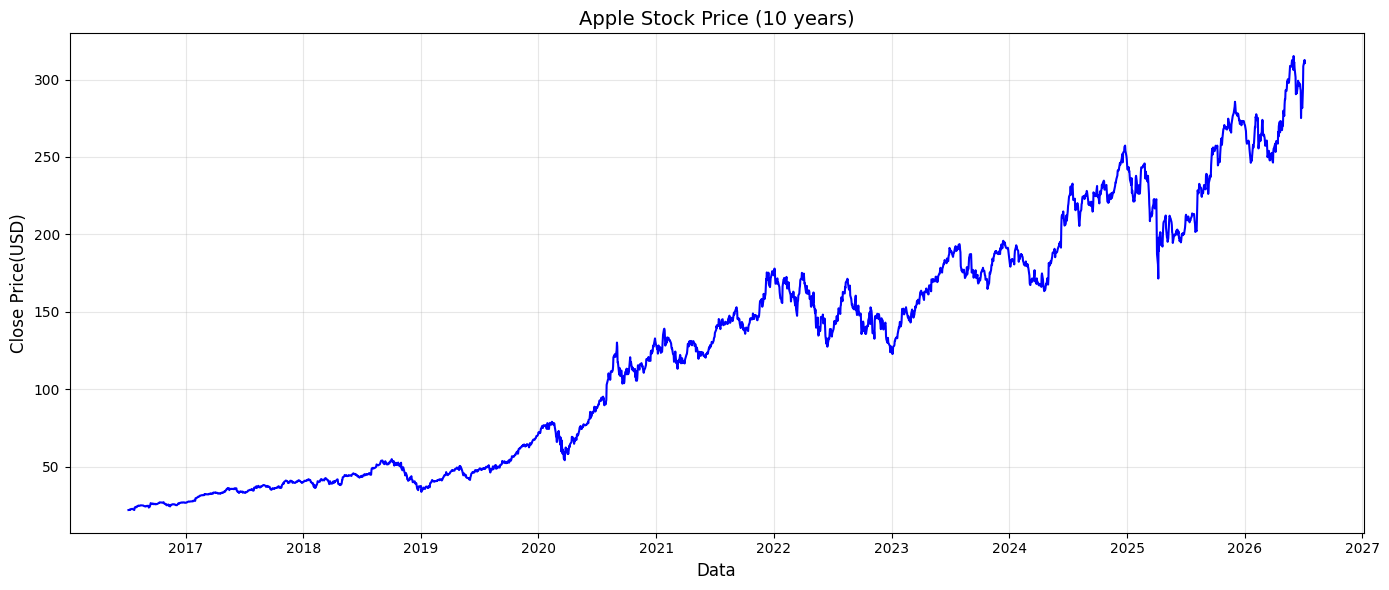

In [4]:
plt.figure(figsize=(14,6))
plt.plot(close_prices.index,close_prices['Close'],color='blue',linewidth=1.5)
plt.title('Apple Stock Price (10 years)',fontsize=14)
plt.xlabel('Data',fontsize=12)
plt.ylabel('Close Price(USD)',fontsize=12)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

Step5. Data Processing

In [5]:
#Get the close price values
dataset=close_prices['Close'].values.reshape(-1,1)

#Scale the data to [0,1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data=scaler.fit_transform(dataset)

#use last 60 days to predicts the next day
look_back=60



Step6. Create The Sequences For RNN

In [6]:
def create_sequences(data,look_back=60):
    # Create sequence for time series prediction
    #look_back=number of previous days to use for prediction
    X,y=[],[]
    for i in range(look_back,len(data)):
        X.append(data[i-look_back:i,0])
        y.append(data[i,0])
    return np.array(X),np.array(y)

#Split data -ensure we have proper test size
total_points=len(scaled_data)
train_size=int(total_points*0.8)

#Critical Fix: Ensure train_size gives enough data for sequence
#We need at least look_back + 50 points for testing
max_test_size=total_points - train_size

if max_test_size<look_back+50:
    train_size=total_points-look_back-50

train_data=scaled_data[:train_size]
test_data=scaled_data[train_size - look_back:]#include ovrelap for sequence creation

print(f"\nTotal Data points: {len(scaled_data)}")
print(f"Training points: {train_size}")
print(f"Test points (including overlap): {len(test_data)}")
print(f"Scaled data range: [{scaled_data.min():.3f}, {scaled_data.max():.3f}]")


#Create Sequences
X_train,y_train=create_sequences(train_data,look_back)
X_test,y_test=create_sequences(test_data,look_back)


#Reshape for RNN input:(sample,time_steps,features)
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\nX_train shape: {X_train.shape}")
print(f"\ny_train shape: {y_train.shape}")
print(f"\nX_test shape: {X_test.shape}")
print(f"\ny_test shape: {y_test.shape}")

#The test dates correspond to the indices after the training data plus look_back
test_start_idx=train_size#Start from where training data ends
test_end_idx=test_start_idx+len(y_test)#End after all test predictions
test_dates=close_prices.index[test_start_idx:test_end_idx]

print(f"\nTest Dates range:{test_dates[0].strftime('%Y-%m-%d')} to {test_dates[-1].strftime('%Y-%m-%d')}")
print(f"Number of test dates:{len(test_dates)}")
print(f"\ny_test_actual_shape:{y_test.shape}")
print(f"test_dates shape:{test_dates.shape}")



Total Data points: 2512
Training points: 2009
Test points (including overlap): 563
Scaled data range: [0.000, 1.000]

X_train shape: (1949, 60, 1)

y_train shape: (1949,)

X_test shape: (503, 60, 1)

y_test shape: (503,)

Test Dates range:2024-07-03 to 2026-07-07
Number of test dates:503

y_test_actual_shape:(503,)
test_dates shape:(503,)


Step7. Build LSTM Model

In [7]:
def create_lstm_model(input_shape):
    #LSTM model with 2 layers
    model=Sequential([
        LSTM(50,return_sequences=True,input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam',loss='mean_squared_error')
    return model

#Create model with the correct input shape
model=create_lstm_model((X_train.shape[1],1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Step8. Callbacks For Better Training

In [8]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)

Step9. Train The Model

In [9]:
#Adjust batch size based on data size
batch_size=min(32,len(X_train)//10)
batch_size=max(8,batch_size)#Ensure batch size is resonable

print(f"Using batch Size:{batch_size}")

history=model.fit(
    X_train,y_train,
    batch_size=batch_size,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stopping,reduce_lr],
    verbose=1
)

Using batch Size:32
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - loss: 0.0128 - val_loss: 6.1358e-04 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0012 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0011 - val_loss: 9.4106e-04 - learning_rate: 0.0010
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 9.2478e-04 - val_loss: 7.8267e-04 - learning_rate: 0.0010
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 8.4009e-04 - val_loss: 5.5691e-04 - learning_rate: 0.0010
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 6.9760e-04 - val_loss: 5.8590e-04 - learning_rate: 0.0010
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 7.6352e-04 - val_loss: 4.9407e-04 - learning_rate: 0.0010
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.8845e-04 - val_loss: 4.7276e-04 - learning_rate: 0.0010
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step 

Step10. Make Prediction

In [10]:
#predict on test data
y_pred=model.predict(X_test)

#Inverse transform to get actual prices
y_test_actual=scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual=scaler.inverse_transform(y_pred)

print(f"\n ny_test_actual shape:{y_test_actual.shape}")
print(f"y_pred_actual shape:{y_pred_actual.shape}")
print(f"test_dates shape:{test_dates.shape}")



16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step

 ny_test_actual shape:(503, 1)
y_pred_actual shape:(503, 1)
test_dates shape:(503,)


Step11. Evaluate The Model

In [11]:
from sklearn.metrics import r2_score
#Calculate the Metrics
rmse=np.sqrt(mean_squared_error(y_test_actual,y_pred_actual))
mae=mean_absolute_error(y_test_actual,y_pred_actual)
r2=r2_score(y_test_actual,y_pred_actual)
mape=np.mean(np.abs((y_test_actual-y_pred_actual)/y_test_actual))*100

print(f"Root Mean Squared Error(RMSE):${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Root Mean Squared Error(RMSE):$13.11
Mean Absolute Error (MAE): $10.87
R² Score: 0.7957
Mean Absolute Percentage Error (MAPE): 4.39%


Step12.Visualization Training History

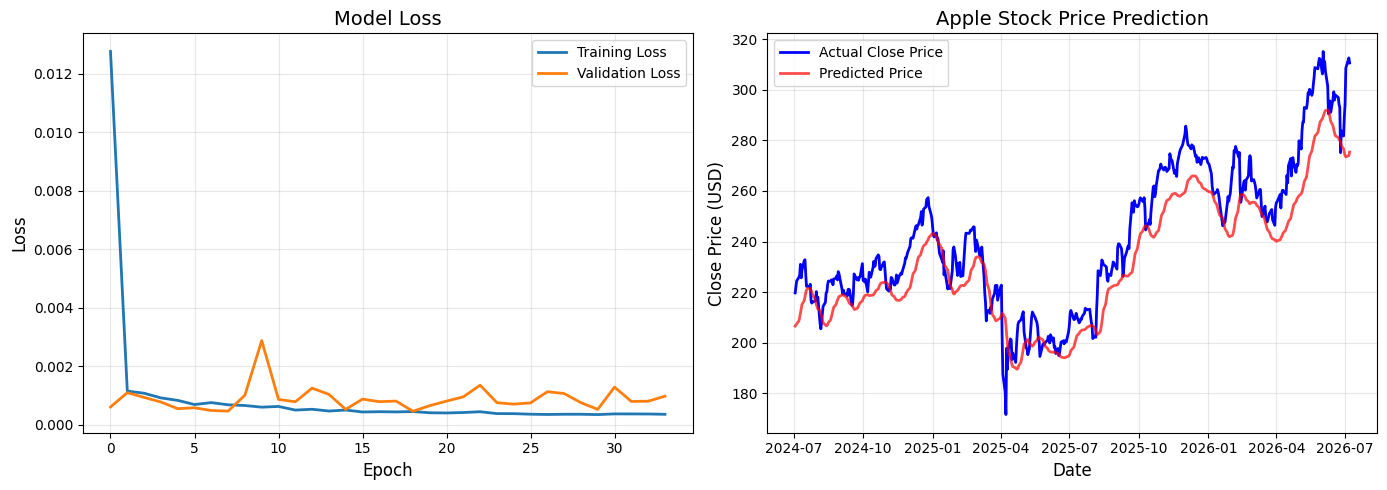

In [12]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].plot(history.history['loss'],label='Training Loss',linewidth=2)
axes[0].plot(history.history['val_loss'],label='Validation Loss',linewidth=2)
axes[0].set_title('Model Loss',fontsize=14)
axes[0].set_xlabel('Epoch',fontsize=12)
axes[0].set_ylabel('Loss',fontsize=12)
axes[0].legend()
axes[0].grid(True,alpha=0.3)


#Prediction vs Actual
# Calculate the start index based on the length difference
start_index = len(test_dates) - len(y_test_actual)

# Slice test_dates to match the prediction arrays
test_dates_aligned = test_dates[start_index:]

axes[1].plot(test_dates, y_test_actual, label='Actual Close Price', color='blue', linewidth=2)
axes[1].plot(test_dates, y_pred_actual, label='Predicted Price', color='red', linewidth=2, alpha=0.7)
axes[1].set_title('Apple Stock Price Prediction', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Close Price (USD)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step14. Actual vs Predicted Scatter

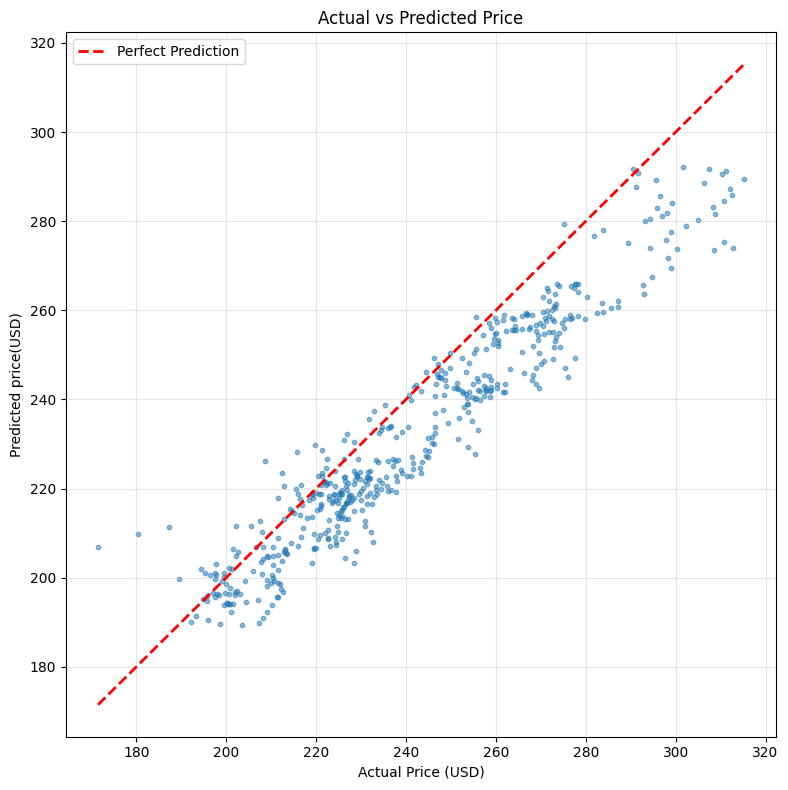

In [13]:
plt.figure(figsize=(8,8))
plt.scatter(y_test_actual,y_pred_actual,alpha=0.5,s=10)
min_val=min(y_test_actual.min(),y_pred_actual.min())
max_val=max(y_test_actual.max(),y_pred_actual.max())
plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2,label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted price(USD)')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()


Step15. Predicted Future Days

In [14]:
def predict_future_days(model,last_sequence,scaler,days_to_predict=30):
    future_predictions=[]
    current_sequence=last_sequence.copy()

    for i in range(days_to_predict):
        #Reshape for prediction
        current_input=current_sequence.reshape(1,look_back,1)

        #Predict next day
        next_pred_scaled=model.predict(current_input,verbose=0)

        #Append prediction
        future_predictions.append(next_pred_scaled[0, 0])

        #Updates sequence:remove first element and add prediction
        current_sequence=np.append(current_sequence[1:],next_pred_scaled[0, 0])

    #Inverse transform to get actual price
    future_predictions=np.array(future_predictions).reshape(-1,1)
    future_prices=scaler.inverse_transform(future_predictions)

    return future_prices.flatten()
#Get the last 'look_back' days from the complete dataset
last_sequence=scaled_data[-look_back:].flatten()

#Predict next 30days
days_to_predict=30
future_prices=predict_future_days(model,last_sequence,scaler,days_to_predict)

#Create future dates(assuming tradings days- Monday to Friday)
last_date=close_prices.index[-1]
future_dates=[]
current_date=last_date
days_added=0

while len(future_dates)<days_to_predict:
    current_date=current_date+pd.Timedelta(days=1)
    #Skip weekends (saturday=5,sunday=6 in pandas)
    #Monday=0, Friday=4
    if current_date.weekday()<5:
        future_dates.append(current_date)


#Create Dataframe with future predictions
future_df=pd.DataFrame({
    'Date':future_dates[:days_to_predict],
    'Predicted_Close':future_dates[:days_to_predict]
})

print(future_df.to_string(index=False))

                     Date           Predicted_Close
2026-07-08 00:00:00-04:00 2026-07-08 00:00:00-04:00
2026-07-09 00:00:00-04:00 2026-07-09 00:00:00-04:00
2026-07-10 00:00:00-04:00 2026-07-10 00:00:00-04:00
2026-07-13 00:00:00-04:00 2026-07-13 00:00:00-04:00
2026-07-14 00:00:00-04:00 2026-07-14 00:00:00-04:00
2026-07-15 00:00:00-04:00 2026-07-15 00:00:00-04:00
2026-07-16 00:00:00-04:00 2026-07-16 00:00:00-04:00
2026-07-17 00:00:00-04:00 2026-07-17 00:00:00-04:00
2026-07-20 00:00:00-04:00 2026-07-20 00:00:00-04:00
2026-07-21 00:00:00-04:00 2026-07-21 00:00:00-04:00
2026-07-22 00:00:00-04:00 2026-07-22 00:00:00-04:00
2026-07-23 00:00:00-04:00 2026-07-23 00:00:00-04:00
2026-07-24 00:00:00-04:00 2026-07-24 00:00:00-04:00
2026-07-27 00:00:00-04:00 2026-07-27 00:00:00-04:00
2026-07-28 00:00:00-04:00 2026-07-28 00:00:00-04:00
2026-07-29 00:00:00-04:00 2026-07-29 00:00:00-04:00
2026-07-30 00:00:00-04:00 2026-07-30 00:00:00-04:00
2026-07-31 00:00:00-04:00 2026-07-31 00:00:00-04:00
2026-08-03 0

Step16. Calculate Predicted Returns And Trends

In [15]:
first_price=future_prices[0]
last_price=future_prices[-1]
price_change=last_price-first_price
price_change_percent=(price_change/first_price)*100

print(f"Starting Price(Day1):${first_price:.2f}")
print(f"Ending Price(Day30):${last_price:.2f}")
print(f"Absolute Change:${price_change:.2f}")
print(f"Percentage Change:${price_change_percent:.2f}%")

#find min and max predicted prices
min_price=future_prices.min()
max_price=future_prices.max()
min_idx=np.argmin(future_prices)
max_idx=np.argmax(future_prices)

print(f"Minimum Price: ${min_price:.2f}(Day{min_idx+1})")
print(f"Maximum Price: ${max_price:.2f}(Day{max_idx+1})")

Starting Price(Day1):$277.25
Ending Price(Day30):$228.28
Absolute Change:$-48.97
Percentage Change:$-17.66%
Minimum Price: $228.28(Day30)
Maximum Price: $277.78(Day2)


Step17. Visualize Historical Data With Future Predictions

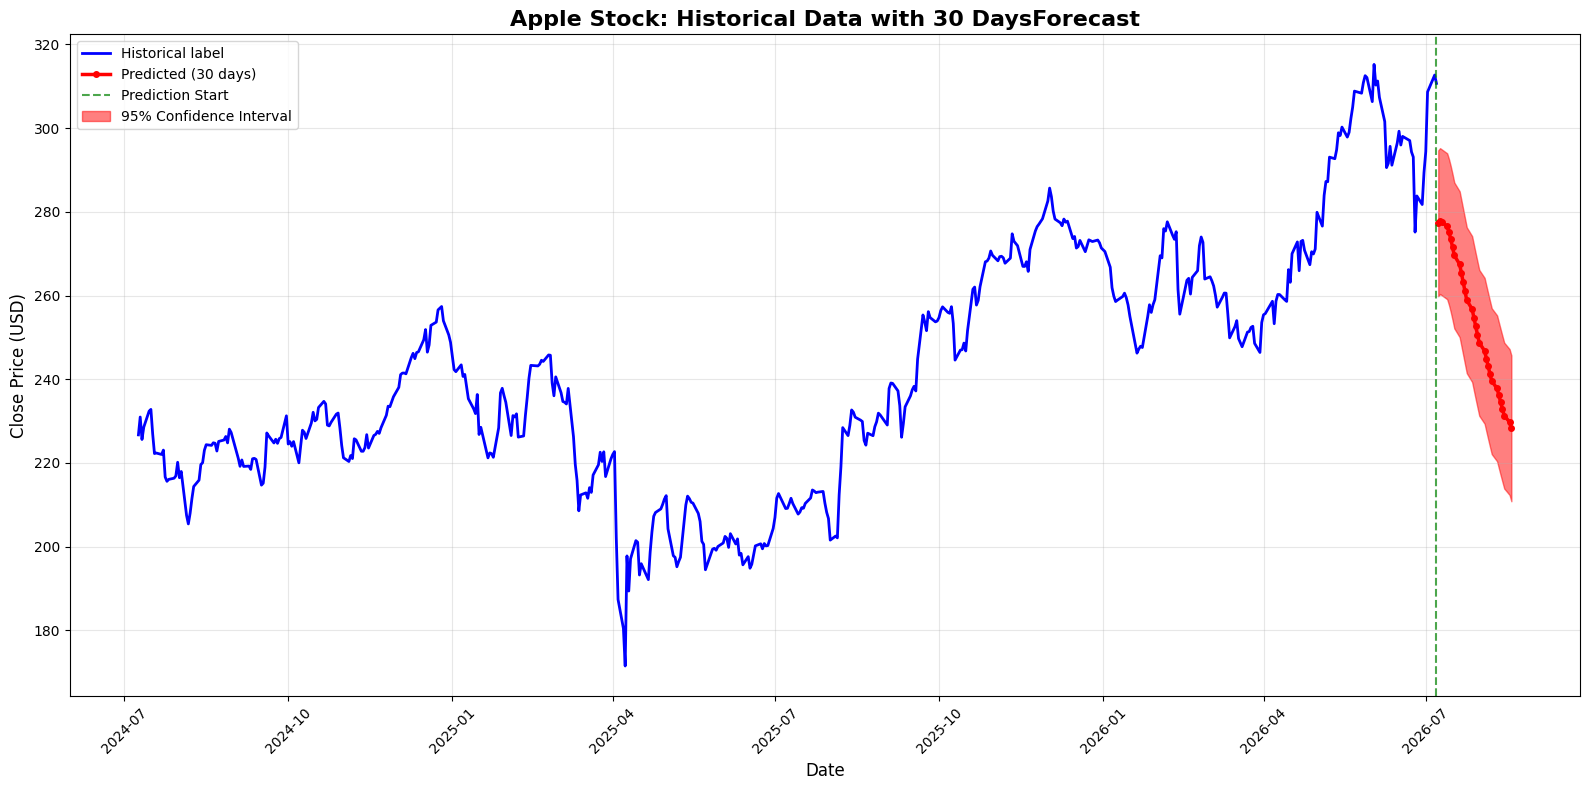

In [19]:
plt.figure(figsize=(16,8))

#plot historical data(last 500 days for better visualization)
history_days=min(500,len(close_prices))
historical_dates=close_prices.index[-history_days:]
historical_prices=close_prices['Close'].values[-history_days:]

plt.plot(historical_dates,historical_prices,label='Historical label',color='blue',linewidth=2)

#Plot Future Prediction
plt.plot(future_dates[:days_to_predict],future_prices[:days_to_predict],label='Predicted (30 days)',color='red',linewidth=2.5,marker='o',markersize=4)

#Add vertical line to seprate historical and predicted
split_date=historical_dates[-1]
plt.axvline(x=split_date,color='green',linestyle='--',linewidth=1.5,alpha=0.7,label='Prediction Start')


#Add confidence interval (simple approximation)
std_dev=np.std(y_test_actual-y_pred_actual)#RMSE from test predictions
upper_bound=future_prices+1.96*std_dev
lower_bound=future_prices-1.96*std_dev


plt.fill_between(future_dates[:days_to_predict],lower_bound[:days_to_predict],upper_bound[:days_to_predict],color='red',alpha=0.5,label='95% Confidence Interval')
plt.title('Apple Stock: Historical Data with 30 DaysForecast',fontsize=16,fontweight='bold')
plt.xlabel('Date',fontsize=12)
plt.ylabel('Close Price (USD)',fontsize=12)
plt.legend(loc='upper left',fontsize=10)
plt.grid(True,alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Step18. Create A Detailed Visulaization With Subplot

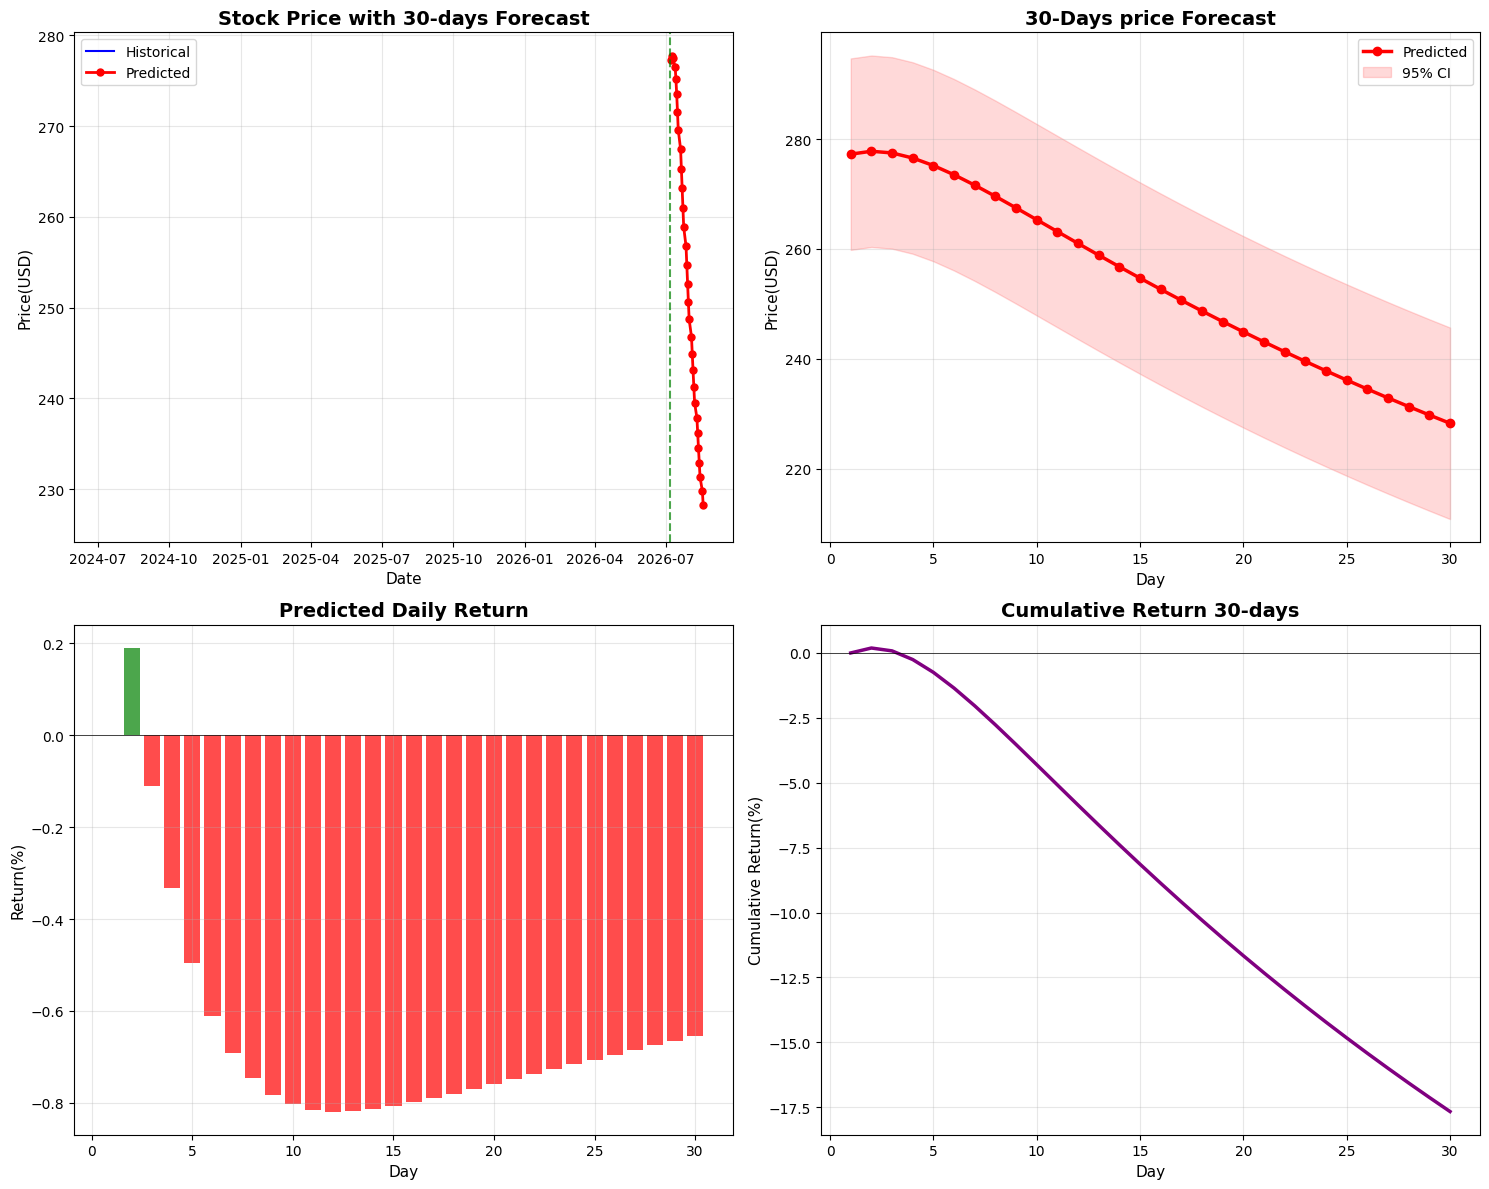

In [28]:
fig, ((ax1,ax2),(ax3,ax4))=plt.subplots(2,2,figsize=(15,12))

#Subplot1: Full Historical + future prediction
ax1.plot(close_prices.index[-500],close_prices['Close'].values[-500],label='Historical',color='blue',linewidth=1.5)
ax1.plot(future_dates[:days_to_predict],future_prices[:days_to_predict],
         label='Predicted',color='red',linewidth=2,marker='o',markersize=5)

ax1.axvline(x=close_prices.index[-1],color='green',linestyle='--',linewidth=1.5,alpha=0.7)
ax1.set_title('Stock Price with 30-days Forecast',fontsize=14,fontweight='bold')
ax1.set_xlabel('Date',fontsize=11)
ax1.set_ylabel('Price(USD)',fontsize=11)
ax1.legend()
ax1.grid(True,alpha=0.3)


#Subplot2: Zoomed future prediction only
ax2.plot(range(1,days_to_predict+1),future_prices,color='red',linewidth=2.5,marker='o',markersize=6,label='Predicted')
ax2.fill_between(range(1, days_to_predict+1),
                 lower_bound, upper_bound,
                 color='red', alpha=0.15, label='95% CI')
ax2.set_title('30-Days price Forecast',fontsize=14,fontweight='bold')
ax2.set_xlabel('Day',fontsize=11)
ax2.set_ylabel('Price(USD)',fontsize=11)
ax2.legend()
ax2.grid(True,alpha=0.3)

#Subplot3: Daily Return Prediction
daily_returns=np.diff(future_prices)/future_prices[:-1]*100
daily_returns=np.append(0,daily_returns)#Add 0 for first day
ax3.bar(range(1,days_to_predict+1),daily_returns,color=['green' if x>=0 else 'red' for x in daily_returns],alpha=0.7)
ax3.set_title('Predicted Daily Return',fontsize=14,fontweight='bold')
ax3.set_xlabel('Day',fontsize=11)
ax3.set_ylabel('Return(%)',fontsize=11)
ax3.axhline(y=0,color='black',linestyle='-',linewidth=0.5)
ax3.grid(True,alpha=0.3)

#Subplot4: Cumulative return
cumulative_return=(future_prices/future_prices[0]-1)*100
ax4.plot(range(1,days_to_predict+1),cumulative_return,color='purple',linewidth=2.5,markersize=4)
ax4.set_title('Cumulative Return 30-days',fontsize=14,fontweight='bold')
ax4.set_xlabel('Day',fontsize=11)
ax4.set_ylabel('Cumulative Return(%)',fontsize=11)
ax4.axhline(y=0,color='black',linestyle='-',linewidth=0.5)
ax4.grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

Step19. Save Predictions to CSV

In [29]:
future_df.to_csv('apple_30_day_prediction.csv',index=False)
print("CSV file Saved")

CSV file Saved


Step20. Summary Statistics

In [31]:
print(f"Average Predicted Price: ${future_prices.mean():.2f}")
print(f"Median Predicted Price: ${np.median(future_prices):.2f}")
print(f"Standard Deviation: ${np.std(future_prices):.2f}")
print(f"Price Volatility: {np.std(daily_returns[1:]):.2f}%")
print(f"Positive Days: {np.sum(daily_returns[1:]>0)} out of {days_to_predict-1}")
print(f"Negative Days: {np.sum(daily_returns[1:]<0)} out of {days_to_predict-1}")

Average Predicted Price: $254.15
Median Predicted Price: $253.67
Standard Deviation: $16.18
Price Volatility: 0.22%
Positive Days: 1 out of 29
Negative Days: 28 out of 29
